<a href="https://colab.research.google.com/github/jaearao/App-155/blob/Assignments/Arao_of_lab_assignment_module4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AP155 Lab Assignment**
## Module 4: Ordinary Differential Equations

_Instructions_: Answer each problem as completely as you can. Discuss **all** your answers as clearly and concisely as possible.

_Scoring Criteria_: 50% - *correctness of code*; 50% - *discussion of the code and results*. Maximum score is **100 points**.


### Student Information

_Full Name (Last Name, First Name)_: John Robert Arao\
_Student No._: 2022-01967\
_Section_: TX-3

### Submission Information

_Date and Time Submitted (most recent upload)_: 11/03/2024 11:56pm

**HONOR PLEDGE** I affirm that I have upheld the highest principles of honesty and integrity in my academic work and that this lab assignment is my own work.

**Sign here with your full name: John Robert Arao**

### Grading Information (c/o Lab Instructor)

TOTAL SCORE: **[]**/100

Score breakdown:
* Problem 1 - []/50
* Problem 2 - []/50

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_

### PROBLEM 1
**The Lotka-Volterra equations**

_Refer to Exercise 8.2 in the Newman text._ The Lotka-Volterra equations are a mathematical model of predator-prey interactions between biological species. Let two variables $x$ and $y$ be proportional to the size of the populations of two species, traditionally called "rabbits" (the prey) and "foxes" (the predators). You could think of $x$ and $y$ as being the population in thousands, say, so that $x = 2$ means there are 2000 rabbits.

In the Lotka-Volterra model the rabbits reproduce at a rate proportional to their population, but are eaten by the foxes at a rate proportional to both their own population and the population of foxes:

$$\frac{{\rm d}x}{{\rm d}t} = \alpha x - \beta xy,$$

where $\alpha$ and $\beta$ are constants. At the same time the foxes reproduce at a rate proportional to the rate at which they eat rabbits-- because they need food to grow and reproduce-- but also die of old age at a rate proportional to their own population:

$$\frac{{\rm d}y}{{\rm d}t}  = \gamma xy - \delta y,$$

where $\gamma$ and $\delta$ are also constants. *(25 pts.)*

1. Solve these equations using the fourth-order Runge-Kutta method for the case $\alpha = 1, \beta = \gamma = 0.5$, and $\delta = 2$, starting from the initial condition $x = y = 2$.

2. Make a graph showing both $x$ and $y$ as a function of time on the same axes from $t =0$ to $t = 30$. *(25 pts.)*

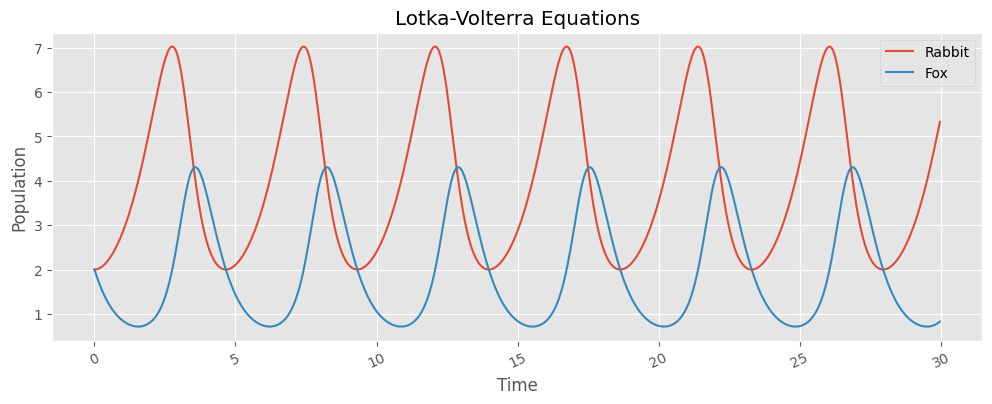

In [ ]:
from math import sin, pi, cos
from numpy import array,arange
import matplotlib.pyplot as plt
import numpy as np

#Define a function for each dervatives and store them in an array
def f(r,t):
    x = r[0]
    y = r[1]
    fx = alpha * x - beta *x*y
    fy = gamma * x * y - delta * y
    return array([fx,fy],float)

#Input the constants and given
alpha = 1.0
beta = 0.5
gamma = 0.5
delta = 2.0
a = 0.0
b = 30.0
N = 1000
h = (b-a)/N

tpoints = arange(a,b,h) #produce na evenly-spaced testing points in time
#define a storage
xpoints = []
ypoints = []

#input the initial conditions
r = array([2.0,2.0],float)

#run the fourth-order Runge-Kutta method
for t in tpoints:
    xpoints.append(r[0])
    ypoints.append(r[1])
    k1 = h*f(r,t)
    k2 = h*f(r+0.5*k1,t+0.5*h)
    k3 = h*f(r+0.5*k2,t+0.5*h)
    k4 = h*f(r+k3,t+h)
    r += (k1+2*k2+2*k3+k4)/6


#Plot the results
plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tpoints,xpoints,label='Rabbit')
ax.plot(tpoints,ypoints,label='Fox')
ax.set_xlabel('Time')
ax.set_ylabel('Population')
ax.set_title('Lotka-Volterra Equations')
plt.xticks(rotation=25)
ax.legend()
plt.show()


## The Fourth-order Runge-Kutta Method

The Taylor expansion of $x(t+h)$ provides a great insight in solving a differential equation.

\begin{align}
    x(t+h) = x(t) + h\frac{dx}{dt} + ...
  \end{align}

This is already powerful, but we can make a more accurate estimate by using the slope of the points inside the $t$ nd $t+h$ and taking their Taylor expansions. With the right linear combinations, we can get the Fourth-order Runge-Kutta Method with an error of order $h^5$.

##Solutions of the Lotka-Volterra equations
From the solutions of the differential equations, it can be visually inferred that the Lotka-Volterra model considers the dependencies of each species' population to each other. The population of the rabbit increases as the population of foxes decreases. This happens until the foxes reproduce with ample nutrients from their prey. Then, when there's too much fox to prey unto the rabbits, the population of rabbits drops and will eventually affect the population of the foxes. This goes periodically, as the model suggests.

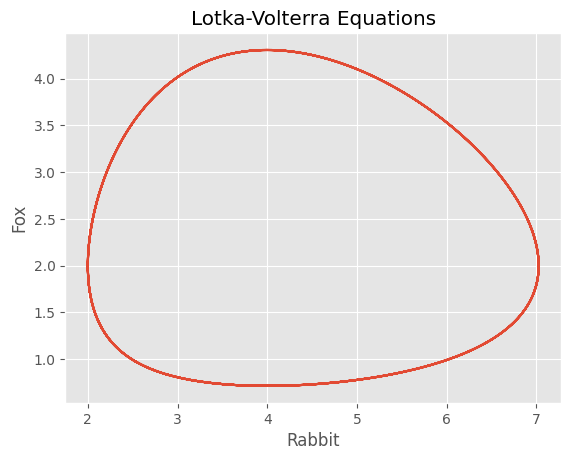

In [ ]:
plt.plot(xpoints,ypoints)
plt.xlabel('Rabbit')
plt.ylabel('Fox')
plt.title('Lotka-Volterra Equations')
plt.show()

Additionally, we can observe their relationship by plotting their population against each other. The plot shows a continous cycle. This is expected with the graph above with respect to time.

> The model suggests a cycle in the population of fox and rabbit that depends on each other.

### PROBLEM 2

**Nonlinear pendulum**

_Refer to Exercise 8.4 in the Newman text._ Building on the results from Example 8.6, calculate the motion of a nonlinear pendulum as follows.

1. Solve the two first-order equations, Eqs. (8.45) and (8.46), using the fourth-order Runge-Kutta method for a pendulum with a 10 cm arm. Use your program to calculate the angle $\theta$ of displacement for several periods of the pendulum when it is released from a standstill at $\theta = 179^\circ$ from the vertical. *(25 pts.)*

2. Make a graph of $\theta$ as a function of time. *(25 pts.)*


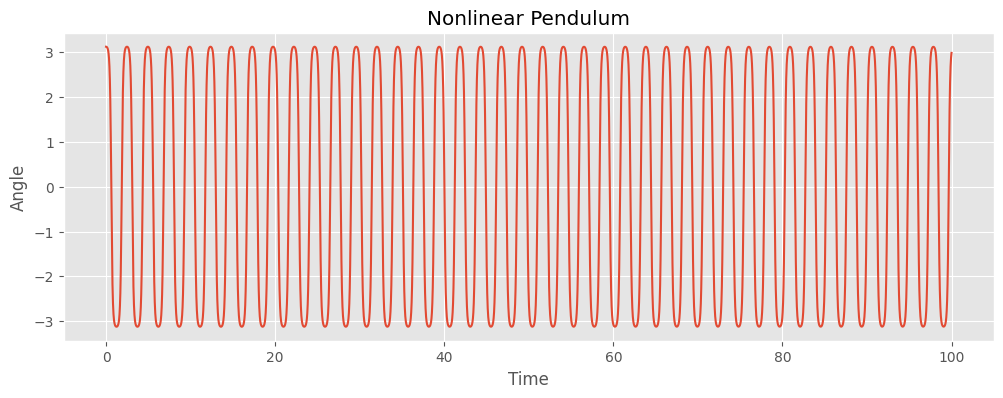

In [ ]:
#Define a function for each dervatives and store them in an array
def y(r,t):
    theta = r[0]
    omega = r[1]
    ftheta = omega
    fomega = -(g/l)*sin(theta)
    return array([ftheta,fomega],float)

#Constants
g = 9.81
l = 0.1

#Initial Conditions
theta = np.radians(179)
omega = 0

#Constants
a = 0.0
b = 100.0
N = 10000

#Test in varying N to test convergence
h = (b-a)/N
h_1 = (b-a)/(5*N)
h_2 = (b-a)/(25*N)

#produce na evenly-spaced testing points in time
tpoints = arange(a,b,h)
tpoints1 = arange(a,b,h_1)
tpoints2 = arange(a,b,h_2)

#run the fourth-order Runge-Kutta method
r = array([theta,omega],float)
r1 = array([theta,omega],float)
r2 = array([theta,omega],float)

def tpoint(r,tpoints,h):
  #define a storage
  thetapoints = []
  omegapoints = []
  for t in tpoints:
    thetapoints.append(r[0])
    omegapoints.append(r[1])
    k1 = h*y(r,t)
    k2 = h*y(r+0.5*k1,t+0.5*h)
    k3 = h*y(r+0.5*k2,t+0.5*h)
    k4 = h*y(r+k3,t+h)
    r += (k1+2*k2+2*k3+k4)/6
  return thetapoints, omegapoints

thetapoints, omegapoints = tpoint(r,tpoints, h)
thetapoints1, omegapoints1 = tpoint(r1,tpoints1, h_1)
thetapoints2, omegapoints2 = tpoint(r2,tpoints2, h_2)

#Plotting
plt.figure(figsize=(12,4))
plt.plot(tpoints,thetapoints)
plt.xlabel('Time')
plt.ylabel('Angle')
plt.title('Nonlinear Pendulum')
plt.show()


##Discussion

The procedure from the Example 8.6 suggests to only modify the $f(r,t)$ of the Example 8.5, which runs from $t = 0$ to $t=100$ and N = 1000. In this configuration, the angle of the non-linear pendulum shows a periodic bahavior for several periods starting from 179 degrees.

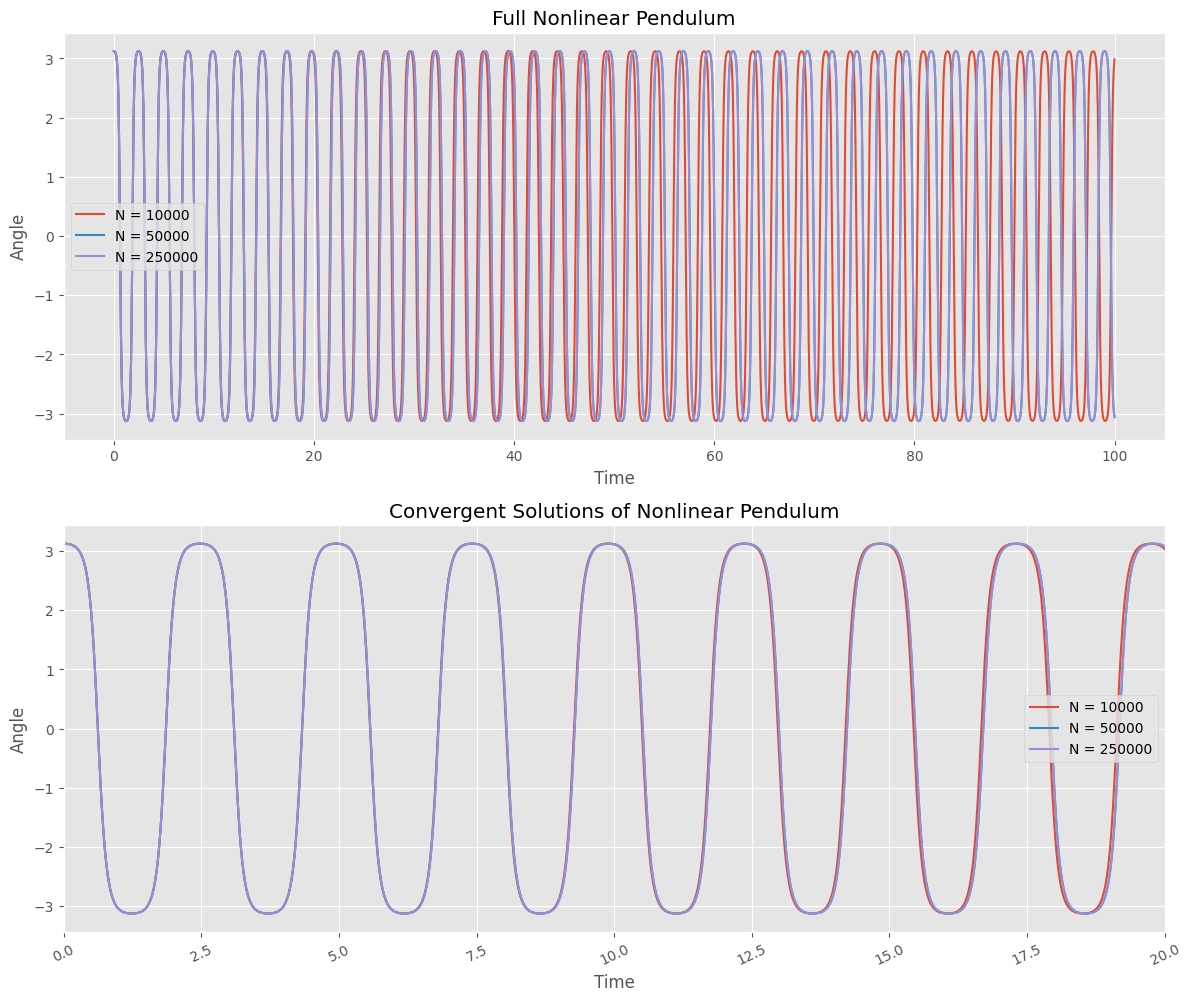

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(12, 10))
ax[0].plot(tpoints,thetapoints)
ax[0].plot(tpoints1,thetapoints1)
ax[0].plot(tpoints2,thetapoints2)
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Angle')
ax[0].set_title('Full Nonlinear Pendulum Solutions')
ax[0].legend(['N = 10000','N = 50000','N = 250000'])

ax[1].plot(tpoints,thetapoints)
ax[1].plot(tpoints1,thetapoints1)
ax[1].plot(tpoints2,thetapoints2)
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Angle')
ax[1].set_title('Convergent Solutions of Nonlinear Pendulum')
ax[1].legend(['N = 10000','N = 50000','N = 250000'])
ax[1].set_xlim(0,20)
fig.tight_layout()
plt.xticks(rotation=25)
plt.show()

##Convergence
To test the convergence of the solution, we can vary the N to 5N and 25N.

As seen in the Full Nonlinear Pendulum Solutions figure, the solutions diverges as time increases. This means that the accuracy of the solution depletes for larger time. Luckily, we can cut the time from 0 to 10, where the solutions perfectly converge. Visually, we can count roughly 4 cycles in 10 seconds.

##Conclusion
> Imposing the instructions of the problem gives the nice solution above. However, the fourth-order Runge-Kutta method is still dependent to N. Hence, considering different N can be beneficial to get the most accurate solution by observing the convergent solutions
